In [14]:
# Goal: a small example to show how to use the forward code.
# Input: far field solutions in k-space from JCM.
# Output: intensity map I(Qx,Qz) in reciprocal space.
# Written by: Ligang Sun.
# Date: 10/15/2025.

In [15]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.append("/home/sun2024/Gitspace/FEM_Inverse2D/source") # update.
from modules.source_config import SourceConfig
from modules.geometry_config  import GeometryConfig, Scatterer
from modules.material_config import MaterialConfig
from modules.cdsaxs_config import CDSAXSConfig
from modules.utils import coordinate_transform, selectsortfun
from modules.FEMProcessing import IntensityFEM, GetMatmeta

In [16]:
# Common parameter.
nanofac=1e-9

def GenColor(N):
    cmap = plt.get_cmap('tab20')  # has 20 distinct colors
    colorarray = ['blue']  # always start with blue
    for i in range(1, N):
        color = cmap(i)  # skip index 0 to avoid repeating blue
        colorarray.append(mcolors.to_hex(color))
    return colorarray
colorarray=GenColor(11)
colorarray[0:5]=['blue','orange','black','green','red','purple']

# material properties. wavelength: 1 nm. 
epsr_Si=9.99435131564694e-1+3.278431066866658e-5j
epsr_W=9.97360870441372e-1+7.893104295072442e-4j

In [17]:
# define light source.
thetaarray=np.linspace(-50,50,101) #*************
lambda0=1e-9 # free space wavelength.*************
E0=1.0 # amplitude of incident electric field.
source = SourceConfig(thetaarray=thetaarray, lambda0=lambda0, E0=E0)

pitch=80*nanofac #***********

dimqxbranch=160 # how many Qx peaks the user wants per branch.

qxpeakarray=np.arange(-10, 11, 1) # only the middle part.
#qxpeakarray=np.arange(-dimqxbranch, dimqxbranch+1, 1) # full range.

#qxpeakarray=qxpeakarray[qxpeakarray != 0]

# define layout.
# (1) Sample frame: z-coordinates for background layer interfaces.
layerzarray=np.array([0, 500000])*nanofac # substrate has thickness being 50 microns.
scatterlayer=[0] # grating structure is on the top layer so index is 0.
scattercoordmat=[]

# (2) JCM frame: [x,z] corrdinates of the vertices of all scatterers. Copy from layout.jcm.
# Order: JCM layout top layer (high JCM z) first. From left to right.
# Points = [-20 0, 20 0, 15 30, -15 30]
vertexmat1 = np.array([[-20, 0], [20, 0],[15, 30],[-15, 30]])*nanofac

vertexmatlist=[vertexmat1] # JCM frame.
scattercoordmat.append(coordinate_transform(vertexmatlist)) # sample frame.

geometry = GeometryConfig(scattercoordmat=scattercoordmat, layerzarray=layerzarray, scatterlayer=scatterlayer)

# define material property.
layerepsrarray=[1.0, epsr_Si, 1.0] # ****************
# Assign material property: JCM layout, from top to bottom, from left to right.
scatterepsrmat=[]
scatterepsrmat.append([epsr_W]) # tungsten grating.

# quick check.
if len(scattercoordmat) != len(scatterepsrmat):
    raise ValueError(f"Mismatch in number of layers: "
                     f"{len(scattercoordmat)} vs {len(scatterepsrmat)}")

for i, (coords, epsr) in enumerate(zip(scattercoordmat, scatterepsrmat)):
    if len(coords) != len(epsr):
        raise ValueError(f"Layer {i}: scattercoordmat has {len(coords)} entries "
                         f"but scatterepsrmat has {len(epsr)}")

material = MaterialConfig(layerepsrarray=layerepsrarray,scatterepsrmat=scatterepsrmat)

config=CDSAXSConfig(pitch=pitch, dimqxbranch=dimqxbranch, source=source, geometry=geometry, material=material)

qxrefarray=np.linspace(-config.dimqxbranch*config.deltaqx,config.dimqxbranch*config.deltaqx,2*config.dimqxbranch+1)
qxindexarray=config.centerindex+qxpeakarray

print(qxindexarray)

[150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167
 168 169 170]


In [18]:
folderoutput = "/home/sun2024/Resource/JCM/Mini_Projects/Examples_for_Github/Case1/Output_all"
Qxmat, Qzmat, Intensitymat, Psiradmat = IntensityFEM(config, folderoutput)
matmetaFEM = GetMatmeta(config, Qxmat, Qzmat, Intensitymat, Psiradmat)
print(matmetaFEM.shape)
print(matmetaFEM[:, qxindexarray, 0].shape)

matmeta generated.
(101, 321, 5)
(101, 21)


In [19]:
QxmatFEM=matmetaFEM[:, qxindexarray, 0].flatten()
QzmatFEM=matmetaFEM[:, qxindexarray, 1].flatten()
IntmatFEM=matmetaFEM[:, qxindexarray, 2].flatten()

mask=IntmatFEM > 0 # this mask is needed for plotting.
QxmatFEM2=QxmatFEM[mask]
QzmatFEM2=QzmatFEM[mask]
IntmatFEM2=np.log10(IntmatFEM[mask])

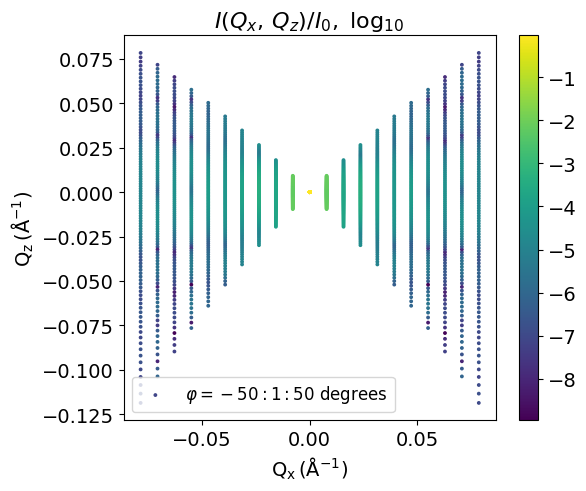

In [34]:
# Now plot the intensity map in the middle area.
plt.figure(figsize=(6,5))
plt.scatter(1e-10*QxmatFEM2, 1e-10*QzmatFEM2, c=IntmatFEM2, cmap='viridis', s=3, label=r"$\varphi=-50:1:50$ degrees")
#plt.axis('equal')
plt.xlabel(r'$\mathrm{Q_x} \, (\mathrm{\AA}^{-1})$',fontsize=14)
plt.ylabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$',fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=14)
plt.title(rf'$I(Q_x,\,Q_z)/I_0,\ \log_{{10}}$',fontsize=16)

cbar = plt.colorbar()
cbar.set_label("",fontsize=14)
cbar.ax.tick_params(labelsize=14)

plt.legend(loc="lower left",fontsize=12)
plt.show()

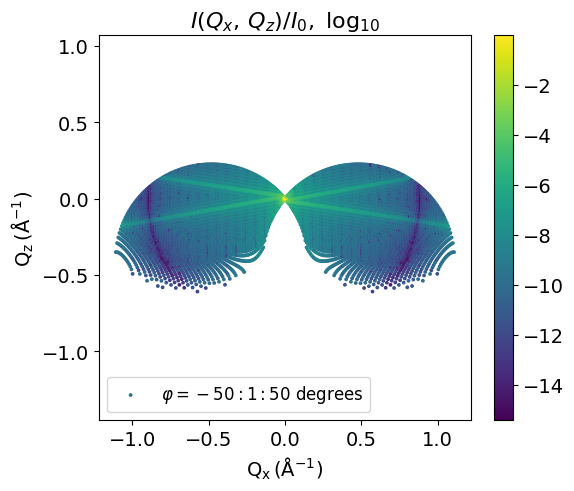

In [6]:
# Now plot the full intensity map.
plt.figure(figsize=(6,5))
plt.scatter(1e-10*QxmatFEM2, 1e-10*QzmatFEM2, c=IntmatFEM2, cmap='viridis', s=3, label=r"$\varphi=-50:1:50$ degrees")
plt.axis('equal')
plt.xlabel(r'$\mathrm{Q_x} \, (\mathrm{\AA}^{-1})$',fontsize=14)
plt.ylabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$',fontsize=14)

plt.tick_params(axis='both', which='major', labelsize=14)
plt.title(rf'$I(Q_x,\,Q_z)/I_0,\ \log_{{10}}$',fontsize=16)

cbar = plt.colorbar()
cbar.set_label("",fontsize=14)
cbar.ax.tick_params(labelsize=14)

plt.legend(loc="lower left",fontsize=12)
plt.show()

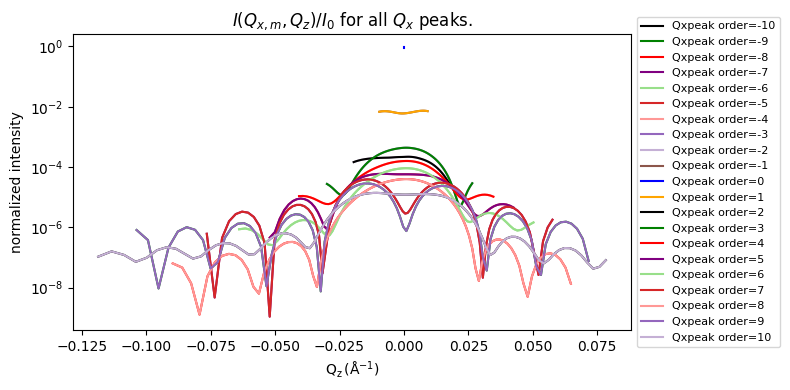

In [40]:
# Now plot all Qx peaks: I(Qz).
plt.figure(figsize=(8, 4))

for i in qxindexarray:
    qxvalue = qxrefarray[i]
    matslice = matmetaFEM[:, i, :]
    Qzarray3, IntFEMarray, thetaarray3, psiradarray3 = selectsortfun(matslice)
    Qzarray3a=Qzarray3*10**(-10)
    plt.plot(Qzarray3a, IntFEMarray,'-', color=colorarray[i-config.dimqxbranch], label=f'Qxpeak order={i-config.dimqxbranch}')

plt.xlabel(r'$\mathrm{Q_z} \, (\mathrm{\AA}^{-1})$')
plt.ylabel('normalized intensity')
plt.yscale('log')
plt.title(r'$I(Q_{x,m}, Q_z)/I_0$ for all $Q_x$ peaks.')
plt.legend(
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    fontsize=8
)
plt.tight_layout()
#plt.grid()

plt.show()